# Notebook 04 — SA-CCR and Regulatory Capital

**quant-desk-toolkit** · github.com/hyun-quant/quant-desk-toolkit

---

SA-CCR (Standardised Approach for Counterparty Credit Risk) is the Basel III framework for computing **Exposure at Default (EAD)** for OTC derivatives. EAD feeds directly into regulatory capital calculations.

This notebook covers:
1. **SA-CCR building blocks**: Maturity Factor, Supervisory Duration, Adjusted Notional
2. **Replacement Cost (RC)**: current loss in a default scenario
3. **PFE Add-on**: forward-looking potential exposure by asset class (IR, FX, Equity)
4. **PFE Multiplier**: overcollateralisation benefit
5. **EAD = α × (RC + PFE)**, α = 1.4
6. **IRB capital**: RWA and minimum capital from the Basel ASRF formula

**Prerequisites**: `instruments.pkl`
**Outputs**: `saccr_results.pkl`


## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sa_ccr import (
    SACCREngine, IRTrade, FXTrade, EquityTrade,
    maturity_factor, supervisory_duration, SUPERVISORY_FACTOR,
    counterparty_rwa,
)
from capital_rwa import (
    CounterpartyCapitalInput, CapitalEngine,
    irb_capital_requirement, asset_correlation, maturity_adjustment,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

with open('instruments.pkl', 'rb') as f:
    inst = pickle.load(f)

print('Setup complete')
print(f'Swap notional : ${inst["swap_notional"]:,.0f}')
print(f'Swap tenor    : {inst["swap_tenor"]}Y')
print(f'Swap MTM      : ${inst["swap_pv_net"]:,.2f}')

Setup complete
Swap notional : $10,000,000
Swap tenor    : 5.0Y
Swap MTM      : $0.00


---
## 1. SA-CCR Building Blocks

**Maturity Factor (MF)**: scales the add-on for remaining life:
- Unmargined: $MF = \sqrt{\min(M, 1)}$ (capped at 1 year)
- Margined:   $MF = \frac{3}{2}\sqrt{MPoR}$

**Supervisory Duration (SD)** for IR trades:
$$SD = \frac{e^{-0.05 S} - e^{-0.05 E}}{0.05}$$

**Adjusted Notional**: $d_i = N_i \times SD_i$ (signed by direction)


In [2]:
print('Maturity Factor (unmargined):')
for M in [0.25, 0.5, 1, 2, 5, 10]:
    mf = maturity_factor(M, margined=False)
    print(f'  M = {M:>5.2f}Y  →  MF = {mf:.4f}')

print()
print('Maturity Factor (margined, MPoR = 10 days = 10/252 yr):')
mpor = 10/252
mf_margined = maturity_factor(mpor, margined=True)
print(f'  MPoR = {mpor:.4f}Y  →  MF = {mf_margined:.4f}')

print()
print('Supervisory Duration (spot-starting swaps):')
for T in [1, 2, 3, 5, 7, 10]:
    sd = supervisory_duration(0, T)
    print(f'  T = {T:>2d}Y  →  SD = {sd:.4f}')

Maturity Factor (unmargined):
  M =  0.25Y  →  MF = 0.5000
  M =  0.50Y  →  MF = 0.7071
  M =  1.00Y  →  MF = 1.0000
  M =  2.00Y  →  MF = 1.0000
  M =  5.00Y  →  MF = 1.0000
  M = 10.00Y  →  MF = 1.0000

Maturity Factor (margined, MPoR = 10 days = 10/252 yr):
  MPoR = 0.0397Y  →  MF = 0.2988

Supervisory Duration (spot-starting swaps):
  T =  1Y  →  SD = 0.9754
  T =  2Y  →  SD = 1.9033
  T =  3Y  →  SD = 2.7858
  T =  5Y  →  SD = 4.4240
  T =  7Y  →  SD = 5.9062
  T = 10Y  →  SD = 7.8694


---
## 2. Case A — 5Y Payer IRS, Unmargined


In [3]:
swap_mtm = inst['swap_pv_net']
notional = inst['swap_notional']
tenor    = inst['swap_tenor']

trade_a = IRTrade(
    notional           = notional,
    maturity           = tenor,
    start_date         = 0.0,
    end_date           = tenor,
    reference_currency = 'USD',
    payer              = True,
    current_mtm        = swap_mtm,
)

engine_a = SACCREngine(
    ir_trades       = [trade_a],
    margined        = False,
    netting_set_mtm = swap_mtm,
    collateral_net  = 0.0,
)

res_a = engine_a.compute()
print('Case A: 5Y Payer IRS, Unmargined')
print(f'  RC              : ${res_a["RC"]:>12,.0f}')
print(f'  IR Add-on       : ${res_a["IR_addon"]:>12,.0f}')
print(f'  Multiplier      : {res_a["multiplier"]:.4f}')
print(f'  PFE add-on      : ${res_a["PFE_addon"]:>12,.0f}')
print(f'  EAD (α×(RC+PFE)): ${res_a["EAD"]:>12,.0f}')

Case A: 5Y Payer IRS, Unmargined
  RC              : $           0
  IR Add-on       : $     221,199
  Multiplier      : 1.0000
  PFE add-on      : $     221,199
  EAD (α×(RC+PFE)): $     309,679


---
## 3. Case B — Same Trade, Margined (10-day MPoR)

In [4]:
engine_b = SACCREngine(
    ir_trades       = [trade_a],
    margined        = True,
    netting_set_mtm = swap_mtm,
    vm_received     = max(swap_mtm, 0),   # assume full VM received
    threshold       = 500_000,
    mta             = 100_000,
    mpor            = 10/252,
)

res_b = engine_b.compute()
print('Case B: 5Y Payer IRS, Margined (10-day MPoR)')
print(f'  RC              : ${res_b["RC"]:>12,.0f}')
print(f'  IR Add-on       : ${res_b["IR_addon"]:>12,.0f}')
print(f'  Multiplier      : {res_b["multiplier"]:.4f}')
print(f'  PFE add-on      : ${res_b["PFE_addon"]:>12,.0f}')
print(f'  EAD (α×(RC+PFE)): ${res_b["EAD"]:>12,.0f}')
print()
print(f'Margining benefit: {res_a["EAD"]/res_b["EAD"]:.2f}x reduction in EAD')

Case B: 5Y Payer IRS, Margined (10-day MPoR)
  RC              : $     600,000
  IR Add-on       : $     741,925
  Multiplier      : 1.0000
  PFE add-on      : $     741,925
  EAD (α×(RC+PFE)): $   1,878,695

Margining benefit: 0.16x reduction in EAD


---
## 4. Case C — Mixed Portfolio (IR + FX + Equity)

In [5]:
trade_ir  = IRTrade(notional=10e6, maturity=5, start_date=0, end_date=5,
                    reference_currency='USD', payer=True, current_mtm=swap_mtm)
trade_fx  = FXTrade(notional=5e6, maturity=1.0, currency_pair='EURUSD',
                    long_foreign=True, current_mtm=50_000)
trade_eq  = EquityTrade(notional=2e6, maturity=2.0, underlying='SPX',
                        is_index=True, long=True, current_mtm=-20_000)

net_mtm_c = swap_mtm + 50_000 - 20_000

engine_c = SACCREngine(
    ir_trades       = [trade_ir],
    fx_trades       = [trade_fx],
    equity_trades   = [trade_eq],
    margined        = False,
    netting_set_mtm = net_mtm_c,
    collateral_net  = 0.0,
)

res_c = engine_c.compute()
print('Case C: Mixed Portfolio (USD IR + EURUSD FX + SPX Equity)')
print(f'  IR Add-on       : ${res_c["IR_addon"]:>12,.0f}')
print(f'  FX Add-on       : ${res_c["FX_addon"]:>12,.0f}')
print(f'  Equity Add-on   : ${res_c["Equity_addon"]:>12,.0f}')
print(f'  Aggregate Add-on: ${res_c["aggregate_addon"]:>12,.0f}')
print(f'  RC              : ${res_c["RC"]:>12,.0f}')
print(f'  Multiplier      : {res_c["multiplier"]:.4f}')
print(f'  EAD             : ${res_c["EAD"]:>12,.0f}')

Case C: Mixed Portfolio (USD IR + EURUSD FX + SPX Equity)
  IR Add-on       : $     221,199
  FX Add-on       : $     200,000
  Equity Add-on   : $     400,000
  Aggregate Add-on: $     821,199
  RC              : $      30,000
  Multiplier      : 1.0000
  EAD             : $   1,191,679


---
## 5. PFE Multiplier Sensitivity

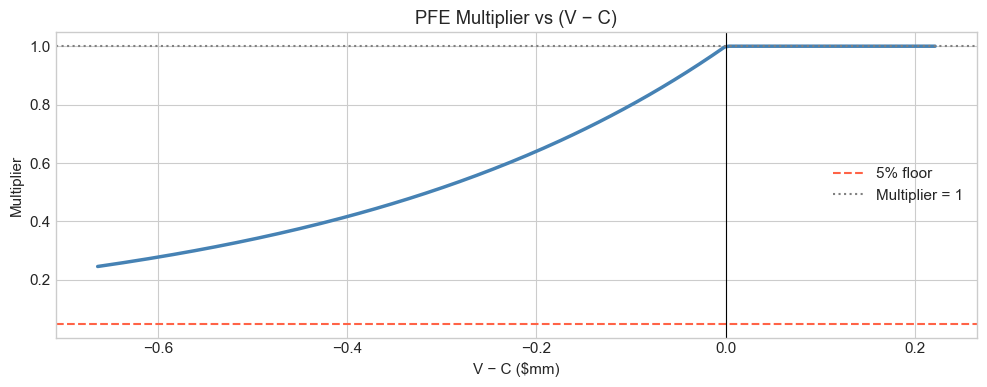

As collateral exceeds MTM (V-C < 0), multiplier falls toward 5% floor.


In [6]:
from sa_ccr import pfe_multiplier

addon = res_a['aggregate_addon']
v_minus_c_range = np.linspace(-3 * addon, addon, 200)
multipliers = [pfe_multiplier(v, 0.0, addon) for v in v_minus_c_range]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(v_minus_c_range / 1e6, multipliers, lw=2.5, color='steelblue')
ax.axhline(y=0.05, color='tomato', ls='--', lw=1.5, label='5% floor')
ax.axhline(y=1.00, color='gray',   ls=':', lw=1.5, label='Multiplier = 1')
ax.axvline(x=0, color='black', lw=0.8)
ax.set_title('PFE Multiplier vs (V − C)')
ax.set_xlabel('V − C ($mm)'); ax.set_ylabel('Multiplier')
ax.legend()
plt.tight_layout(); plt.savefig('nb04_multiplier.png', dpi=120, bbox_inches='tight'); plt.show()
print('As collateral exceeds MTM (V-C < 0), multiplier falls toward 5% floor.')

---
## 6. IRB Capital Formula (Basel ASRF)

The Basel III IRB formula for corporate/FI counterparties:

$$R = 0.12 \cdot \frac{1-e^{-50 PD}}{1-e^{-50}} + 0.24 \cdot \left(1 - \frac{1-e^{-50 PD}}{1-e^{-50}}\right)$$

$$K = LGD \cdot \left[N\left(\sqrt{\frac{R}{1-R}}G(PD) + \sqrt{\frac{1}{1-R}}G(0.999)\right) - PD\right] \cdot MA$$

$$RWA = 12.5 \times EAD \times K, \quad Capital = 8\% \times RWA$$


In [7]:
# Capital for Case A: BBB counterparty, 1% PD, 45% LGD
cp_input = CounterpartyCapitalInput(
    name              = 'BBB_Corp',
    ead               = res_a['EAD'],
    pd                = 0.01,
    lgd               = 0.45,
    maturity          = 5.0,
    credit_quality    = 'BBB',
    counterparty_type = 'Corporate_BBB',
    is_financial      = False,
)

cap_engine = CapitalEngine([cp_input], use_irb=True, use_sa_cva=False)
cap_result = cap_engine.compute()
ccr        = cap_result['CCR']['BBB_Corp']

print('Basel III IRB Capital — Case A (unmargined 5Y IRS, BBB cpty)')
print(f'  EAD          : ${res_a["EAD"]:>12,.0f}')
print(f'  Asset corr R : {ccr["R"]:.4f}')
print(f'  Maturity adj : {ccr["MA"]:.4f}')
print(f'  K (capital %) : {ccr["K"]*100:.4f}%')
print(f'  RWA (CCR)    : ${ccr["RWA_CCR"]:>12,.0f}')
print(f'  EL           : ${ccr["EL"]:>12,.0f}')
print(f'  Min Capital  : ${cap_result["capital_min"]["Total_min"]:>12,.0f}  (8% × RWA)')

Basel III IRB Capital — Case A (unmargined 5Y IRS, BBB cpty)
  EAD          : $     309,679
  Asset corr R : 0.1928
  Maturity adj : 1.6928
  K (capital %) : 74.6041%
  RWA (CCR)    : $   2,887,914
  EL           : $       1,394
  Min Capital  : $     234,458  (8% × RWA)


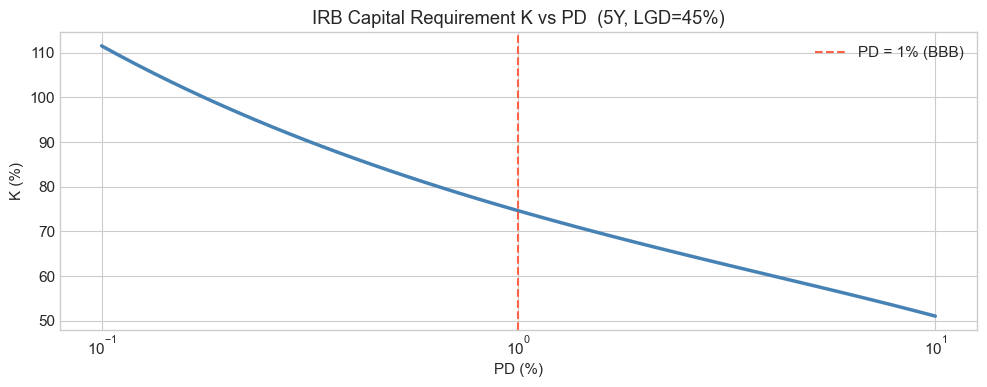

In [8]:
# Capital sensitivity to PD
pds      = np.logspace(-3, -1, 50)  # 0.1% to 10%
capitals = []
for pd in pds:
    res = irb_capital_requirement(res_a['EAD'], pd, lgd=0.45, maturity=5.0)
    capitals.append(res['K'] * 100)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(pds*100, capitals, lw=2.5, color='steelblue')
ax.axvline(x=1.0, color='tomato', ls='--', lw=1.5, label='PD = 1% (BBB)')
ax.set_title('IRB Capital Requirement K vs PD  (5Y, LGD=45%)')
ax.set_xlabel('PD (%)'); ax.set_ylabel('K (%)')
ax.legend()
plt.tight_layout(); plt.savefig('nb04_capital_pd.png', dpi=120, bbox_inches='tight'); plt.show()

---
## 7. EAD Comparison and Netting Benefit

In [9]:
# Payer + receiver netting demonstration
trade_recv = IRTrade(notional=notional, maturity=tenor, start_date=0, end_date=tenor,
                     reference_currency='USD', payer=False, current_mtm=-swap_mtm)

# Without netting: two separate trades
ead_payer    = SACCREngine(ir_trades=[trade_a], netting_set_mtm=swap_mtm).compute()['EAD']
ead_receiver = SACCREngine(ir_trades=[trade_recv], netting_set_mtm=-swap_mtm).compute()['EAD']

# With netting: bilateral close-out
net_mtm_both = swap_mtm + (-swap_mtm)  # = 0 (perfect offset)
ead_netted   = SACCREngine(ir_trades=[trade_a, trade_recv], netting_set_mtm=net_mtm_both).compute()['EAD']

print('Netting Benefit Demonstration')
print(f'  EAD payer swap         : ${ead_payer:>12,.0f}')
print(f'  EAD receiver swap      : ${ead_receiver:>12,.0f}')
print(f'  Sum (no netting)       : ${ead_payer + ead_receiver:>12,.0f}')
print(f'  EAD netted (bilateral) : ${ead_netted:>12,.0f}')
print(f'  Netting benefit        : ${ead_payer + ead_receiver - ead_netted:>12,.0f}  ({(1-ead_netted/(ead_payer+ead_receiver))*100:.1f}% reduction)')

Netting Benefit Demonstration
  EAD payer swap         : $     309,679
  EAD receiver swap      : $     309,679
  Sum (no netting)       : $     619,358
  EAD netted (bilateral) : $           0
  Netting benefit        : $     619,358  (100.0% reduction)


---
## 8. Save Outputs

In [10]:
saccr_results = {
    'case_a'     : res_a,
    'case_b'     : res_b,
    'case_c'     : res_c,
    'capital_a'  : cap_result,
    'trade_notional' : notional,
    'trade_tenor'    : tenor,
    'trade_mtm'      : swap_mtm,
}
with open('saccr_results.pkl', 'wb') as f:
    pickle.dump(saccr_results, f)
print('Saved saccr_results.pkl')
print('Proceed to: notebook_05_margin_simm.ipynb')

Saved saccr_results.pkl
Proceed to: notebook_05_margin_simm.ipynb
